In [1]:
import sys
import subprocess

# Function to install packages silently, if needed
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

# Install duckdb package if not already installed
install_package('duckdb')
install_package('sweetviz')


# Import necessary libraries
import pandas as pd
import duckdb
import pyarrow.parquet as pq
from plotnine import ggplot, aes, geom_bar, coord_flip, theme_minimal, labs
import sweetviz as sv


# Define the path to the Parquet files
parquet_path = '/kaggle/input/star-wars/parquet_files/'

# Load Parquet files into pandas DataFrames
characters = pd.read_parquet(parquet_path + 'characters.parquet')
species = pd.read_parquet(parquet_path + 'species.parquet')
planets = pd.read_parquet(parquet_path + 'planets.parquet')
starships = pd.read_parquet(parquet_path + 'starships.parquet')
weapons = pd.read_parquet(parquet_path + 'weapons.parquet')
organizations = pd.read_parquet(parquet_path + 'organizations.parquet')
music = pd.read_parquet(parquet_path + 'music.parquet')
vehicles = pd.read_parquet(parquet_path + 'vehicles.parquet')
cities = pd.read_parquet(parquet_path + 'cities.parquet')
films = pd.read_parquet(parquet_path + 'films.parquet')
droids = pd.read_parquet(parquet_path + 'droids.parquet')
quotes = pd.read_parquet(parquet_path + 'quotes.parquet')
events = pd.read_parquet(parquet_path + 'events.parquet')
battles = pd.read_parquet(parquet_path + 'battles.parquet')
timeline = pd.read_parquet(parquet_path + 'timeline.parquet')

In [2]:
characters.head()

,id,name,species,gender,height,weight,hair_color,eye_color,skin_color,year_born,homeworld,year_died,description
0,1,Luke Skywalker,Human,Male,1.72,77.0,Blond,Blue,Light,19.0,Tatooine,34.0,The main protagonist of the original trilogy.
1,2,Leia Organa,Human,Female,1.50,49.0,Brown,Brown,Light,19.0,Alderaan,35.0,A leader in the Rebel Alliance and twin sister...
2,3,Darth Vader,Human,Male,2.02,136.0,None,Yellow,Pale,41.0,Tatooine,4.0,The Sith Lord formerly known as Anakin Skywalker.
3,4,Yoda,Yoda's species,Male,0.66,17.0,White,Brown,Green,896.0,Unknown,4.0,A wise and powerful Jedi Master.
4,5,Han Solo,Human,Male,1.80,80.0,Brown,Hazel,Light,29.0,Corellia,34.0,A smuggler turned hero in the Rebel Alliance.


                                             |          | [  0%]   00:00 -> (? left)


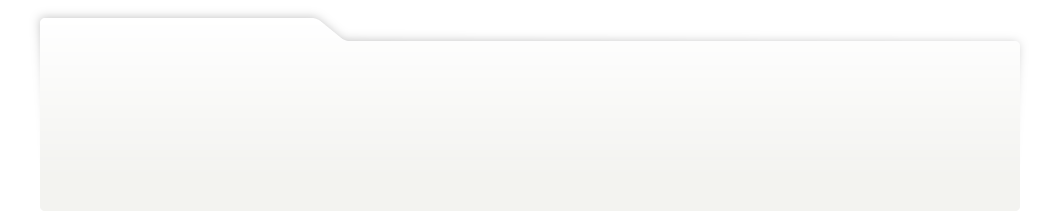
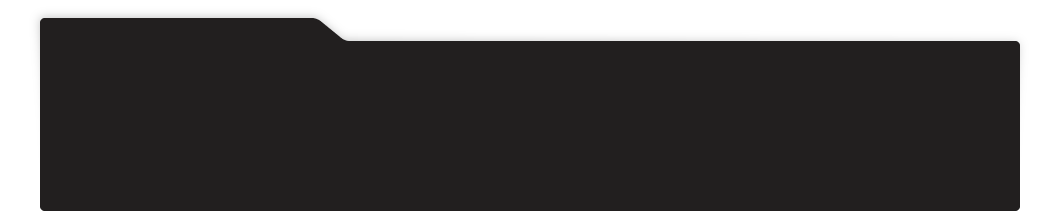
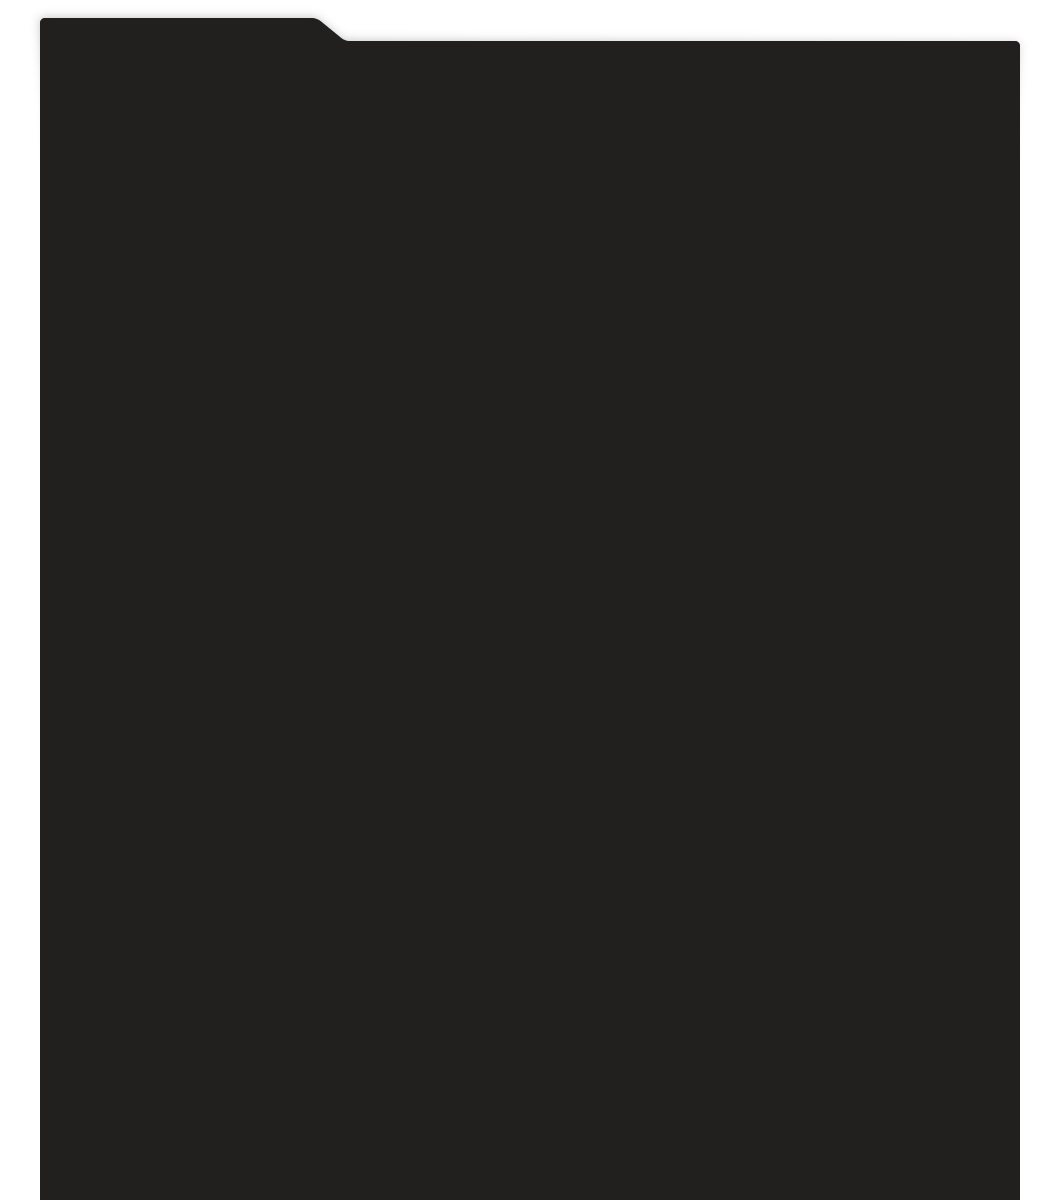
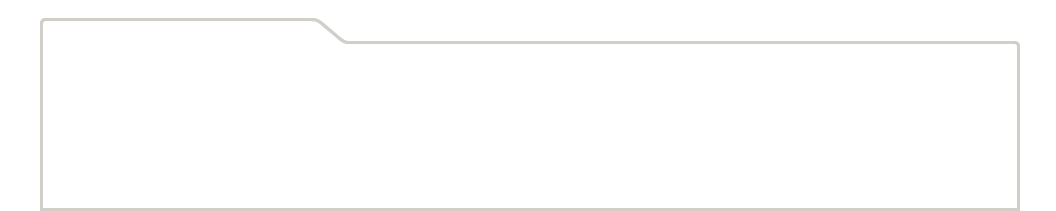
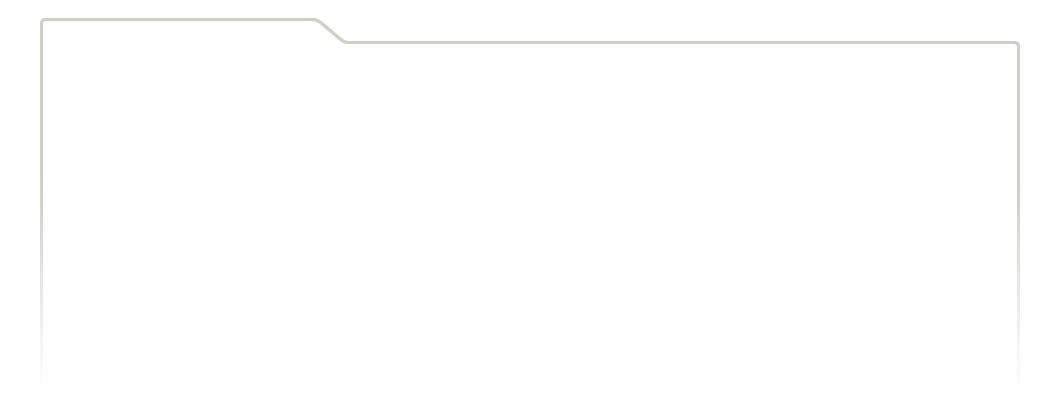
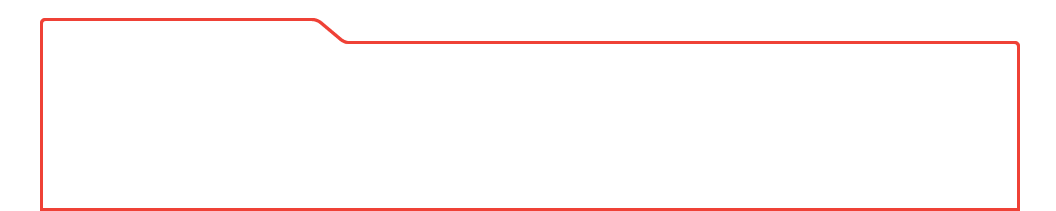
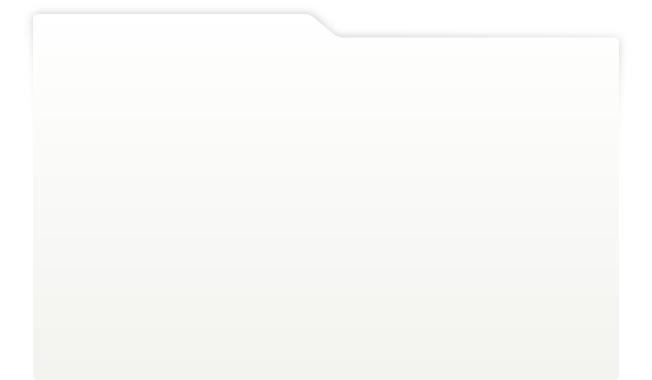
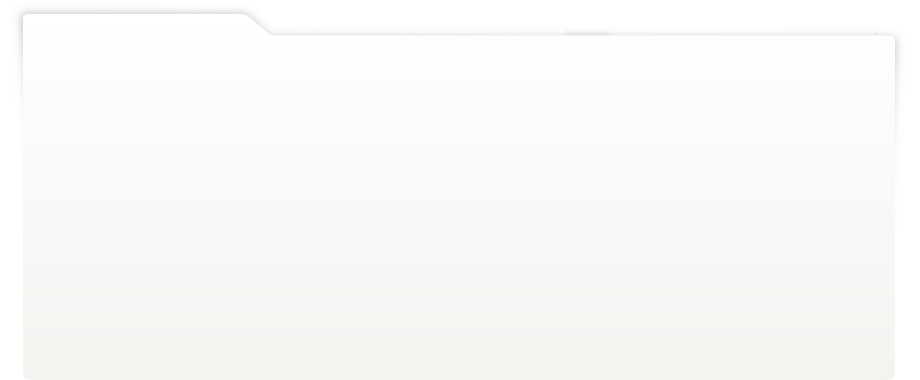
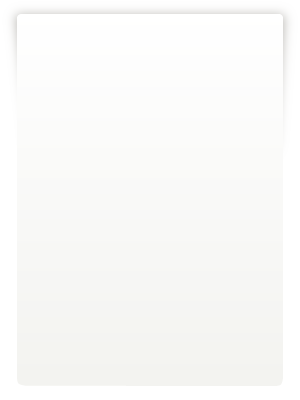
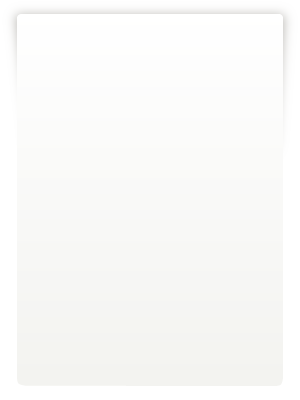
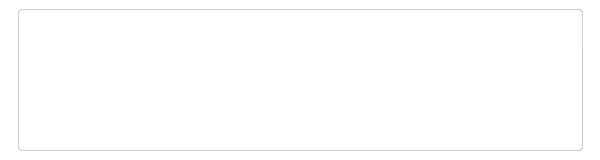
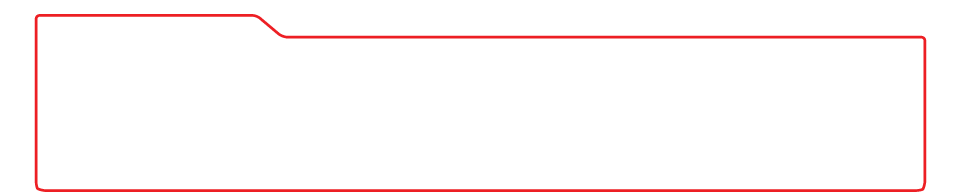
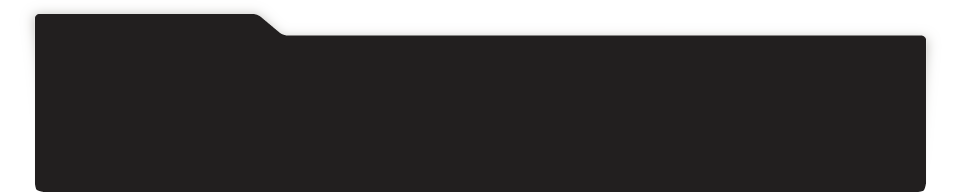
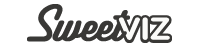
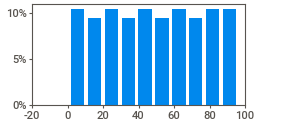
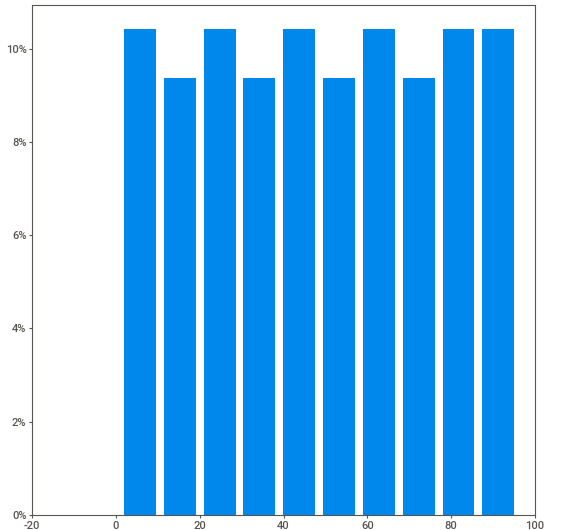
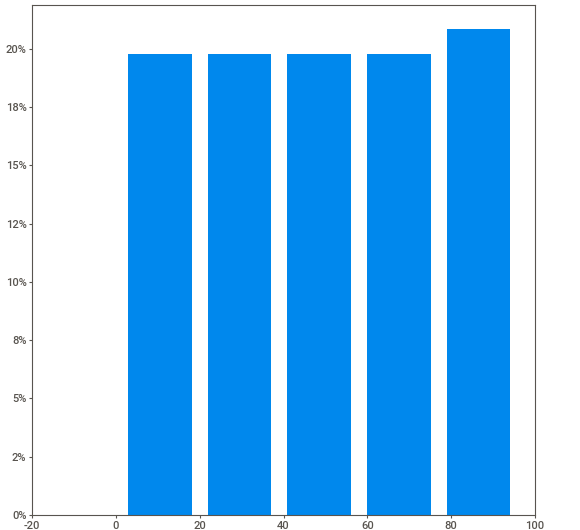
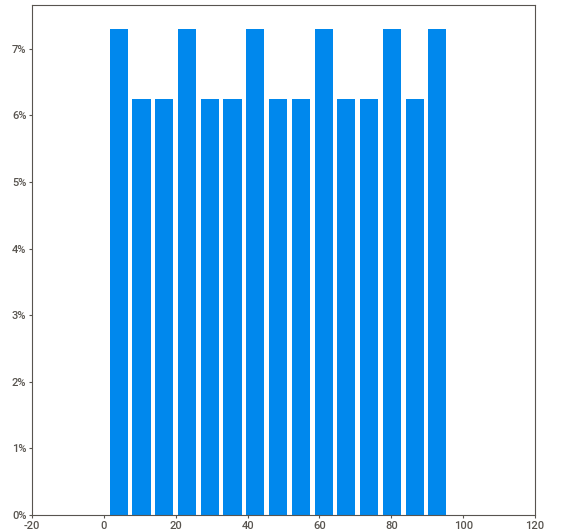
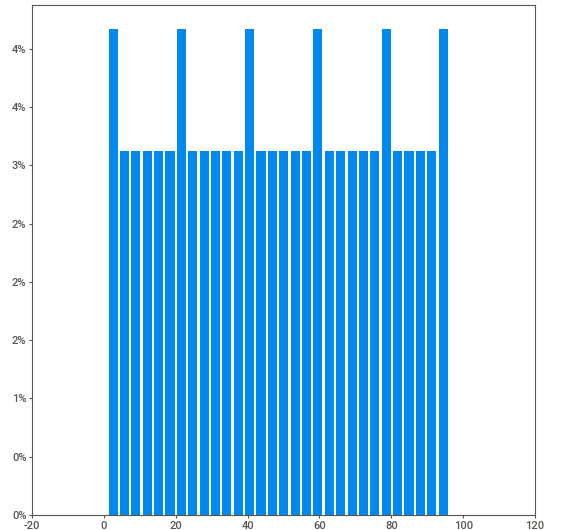
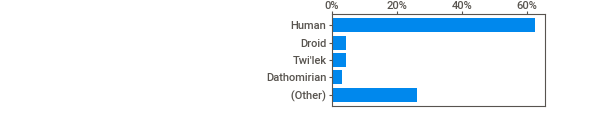
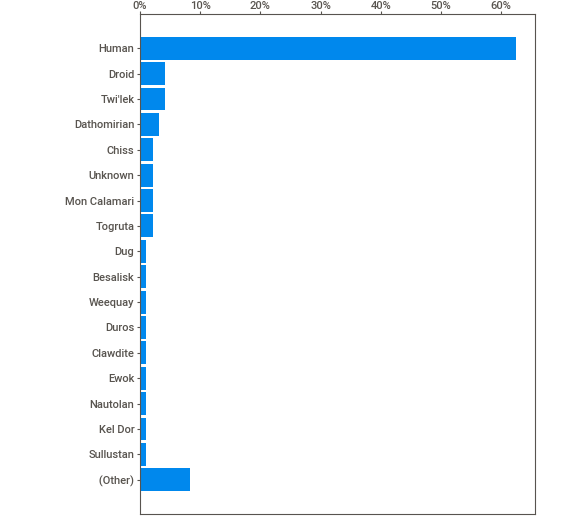
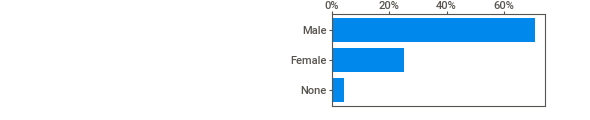
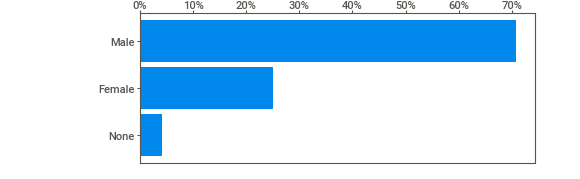
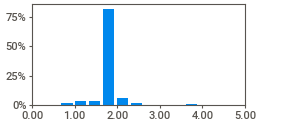
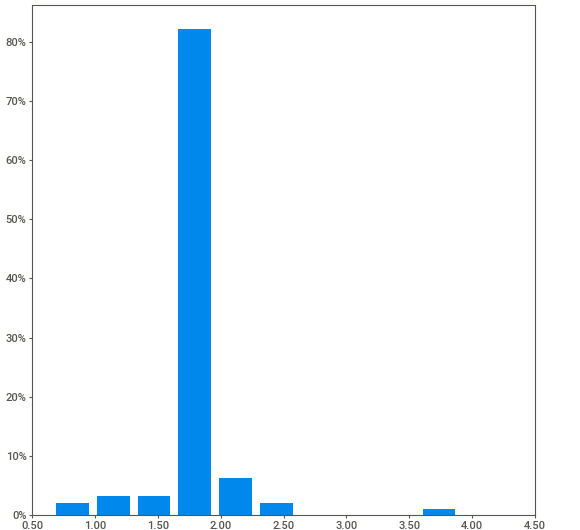
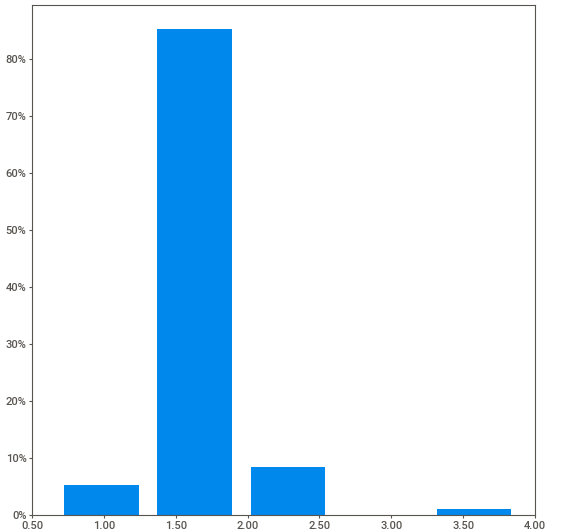
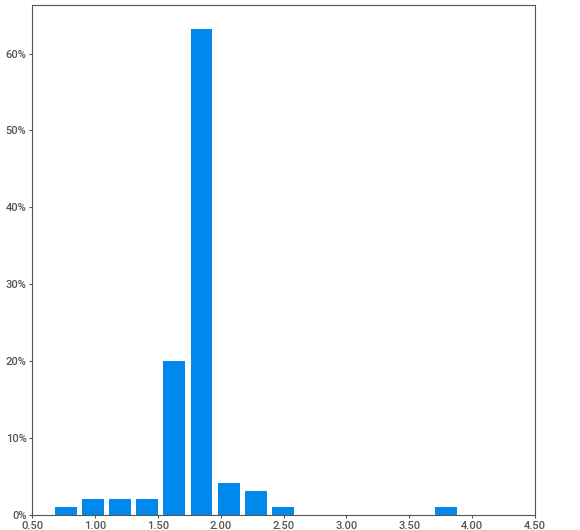
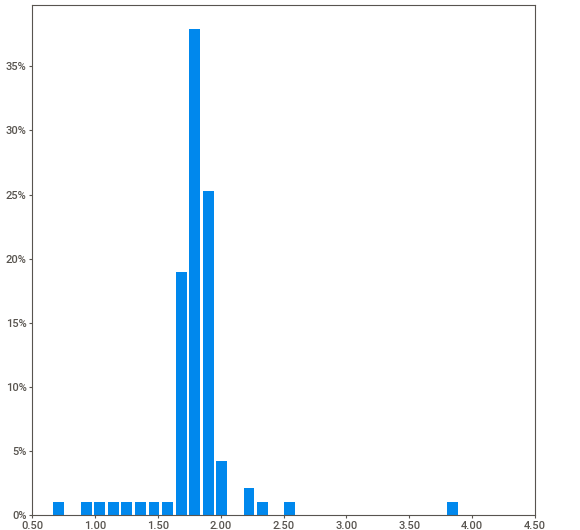
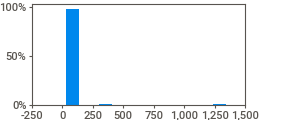
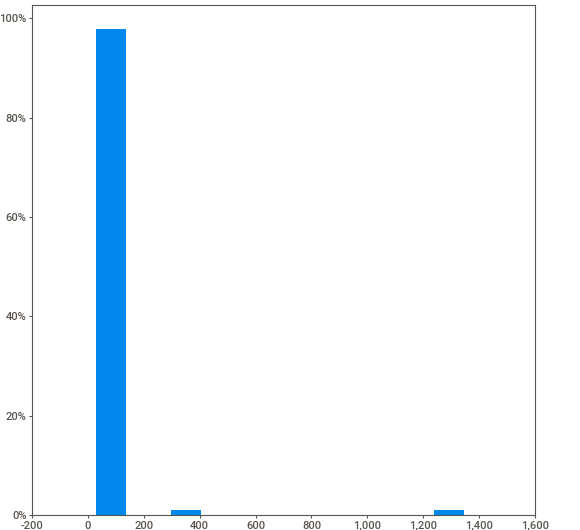
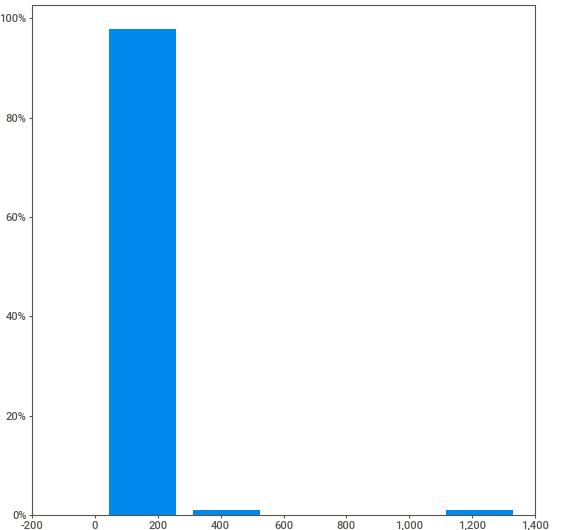
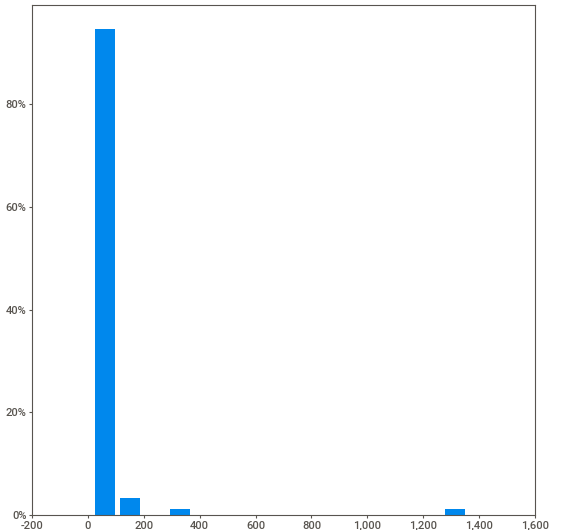
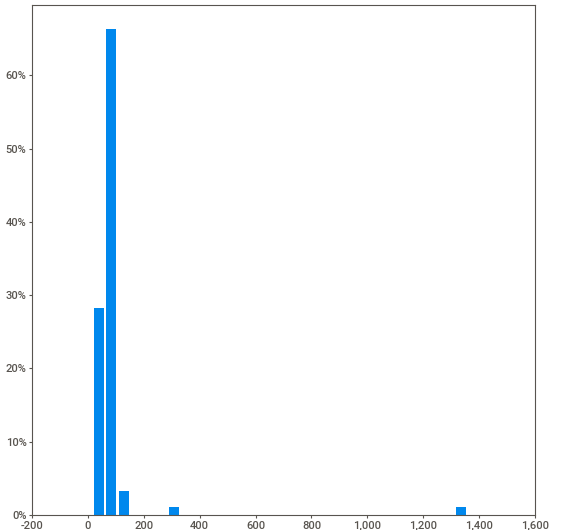
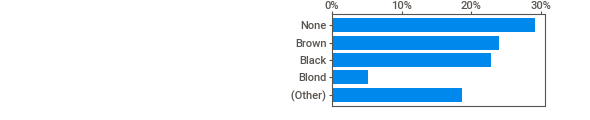
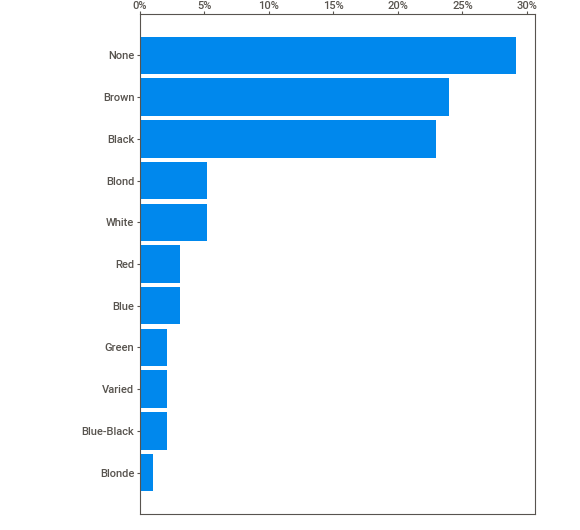
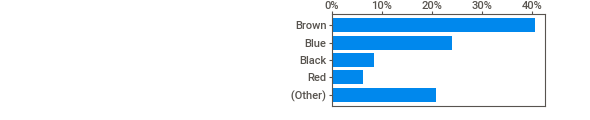
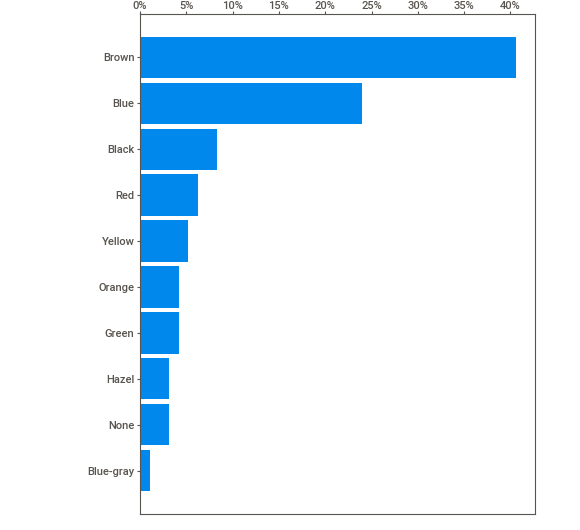
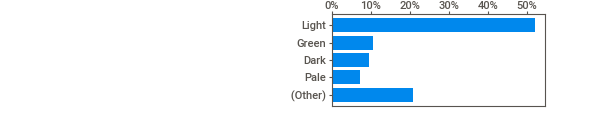
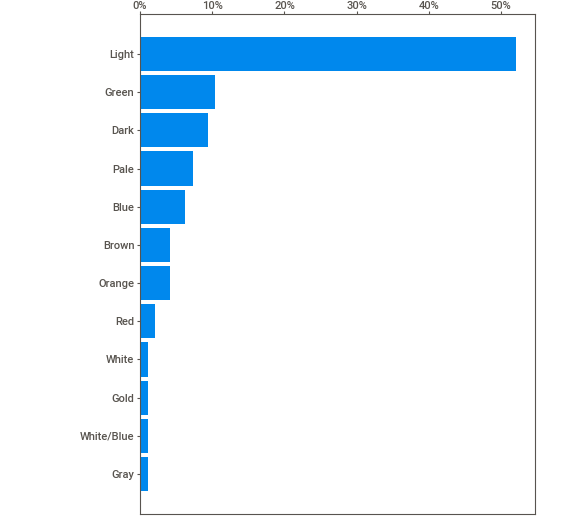
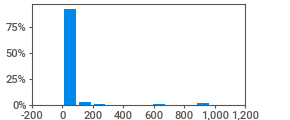
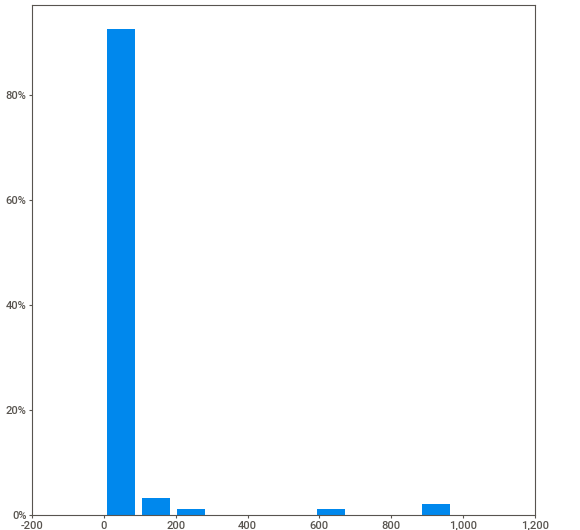
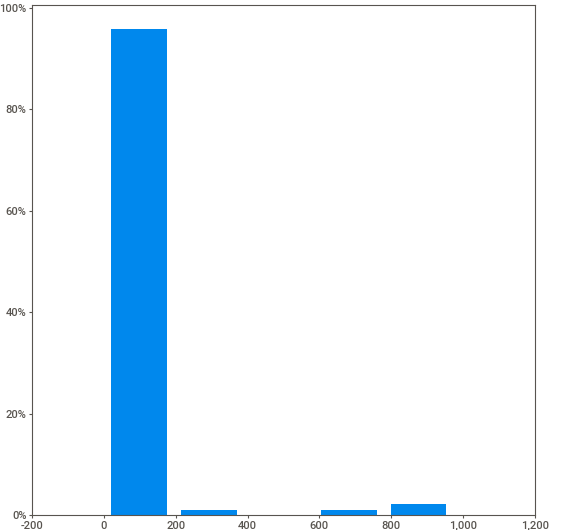
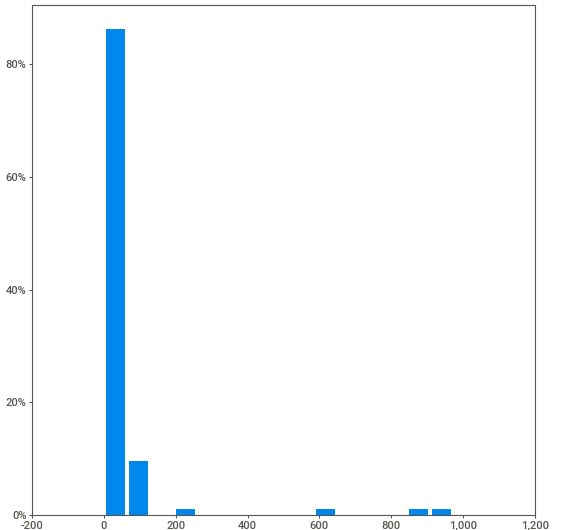
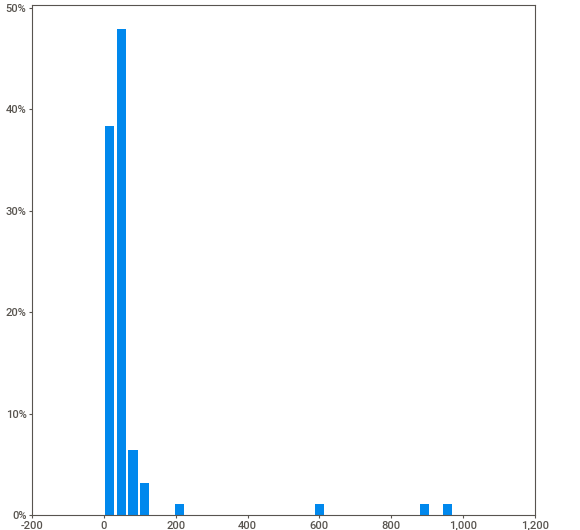
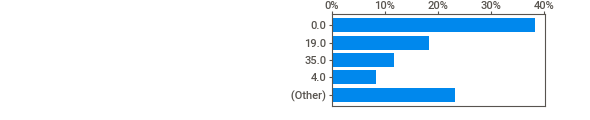
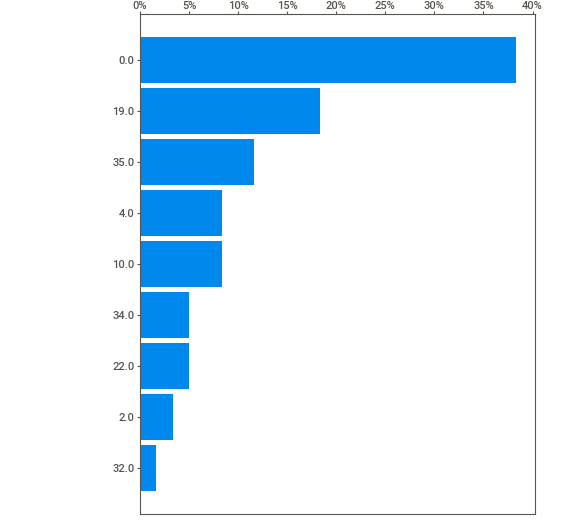
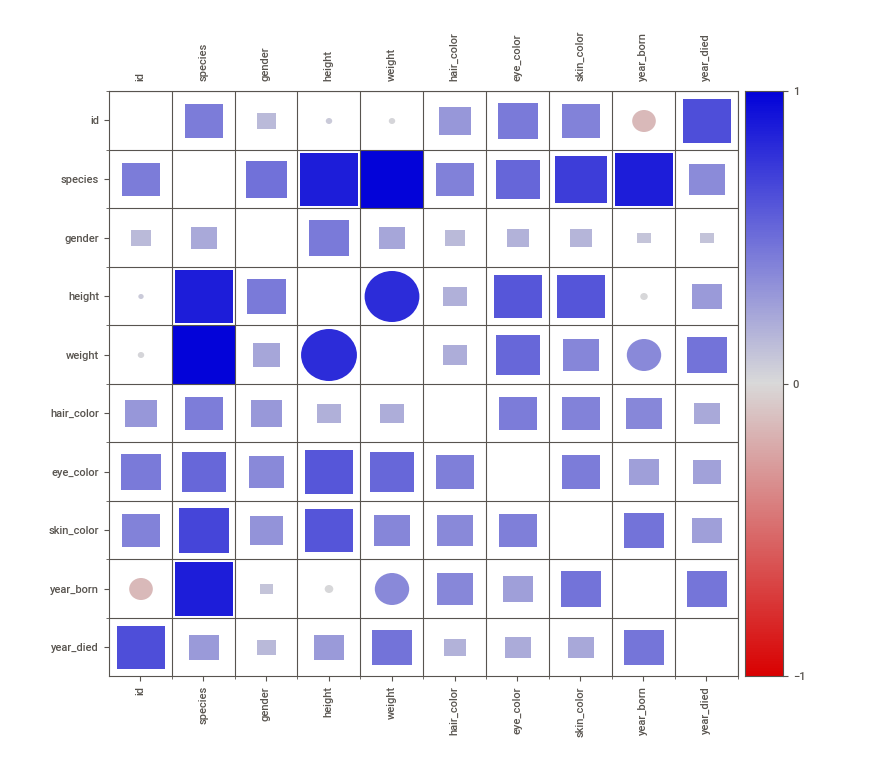
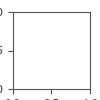

In [3]:
# Analyze the dataframe
my_report = sv.analyze(characters)
my_report.show_notebook(layout='vertical')

# Query Parquet Files Directly Using DuckDB

In [4]:
# Create a connection to an in-memory DuckDB database
con = duckdb.connect()

# Query the characters Parquet file directly using DuckDB
query = """
    SELECT species, COUNT(*) as count
    FROM read_parquet('{parquet_path}characters.parquet')
    GROUP BY species
    ORDER BY count DESC
""".format(parquet_path=parquet_path)

character_species_count_duckdb = con.execute(query).fetchdf()
character_species_count_duckdb

,species,count
0,Human,60
1,Droid,4
2,Twi'lek,4
3,Dathomirian,3
4,Unknown,2
5,Mon Calamari,2
6,Chiss,2
7,Togruta,2
8,Gungan,1
9,Hutt,1


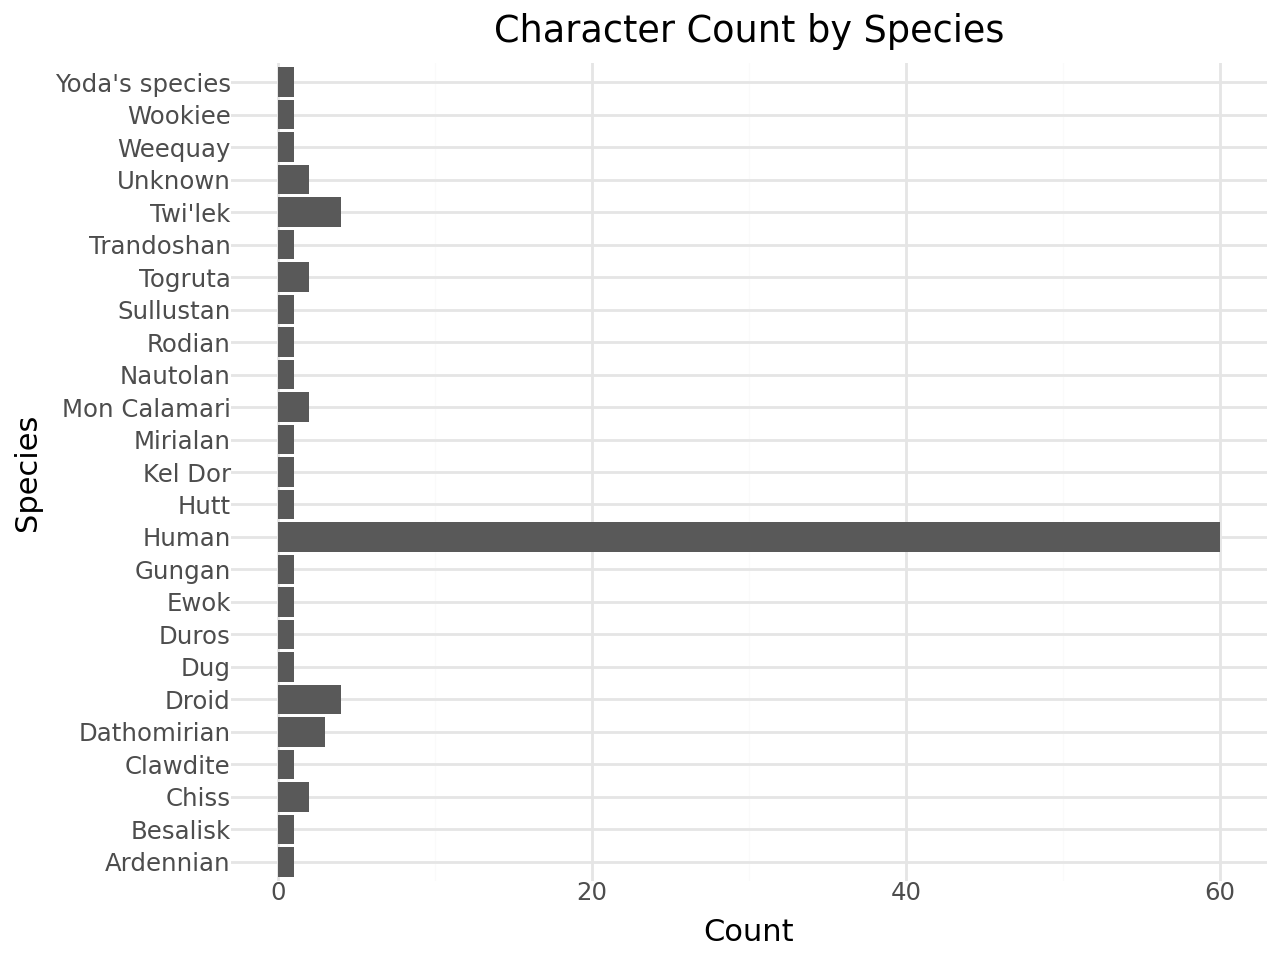

In [5]:
# Create a horizontal bar chart of character count by species using plotnine
p = (
    ggplot(characters, aes(x='species')) +
    geom_bar() +
    coord_flip() +  # This flips the coordinates to make a horizontal bar chart
    theme_minimal() +
    labs(title='Character Count by Species',
         x='Species',
         y='Count')
)

# Display the plot
p.show()

In [6]:
# Example: Join characters with planets using DuckDB
query = """
    SELECT c.name as character, p.name as homeworld
    FROM read_parquet('{parquet_path}characters.parquet') c
    JOIN read_parquet('{parquet_path}planets.parquet') p
    ON c.homeworld = p.name
    LIMIT 10
""".format(parquet_path=parquet_path)

characters_homeworld_duckdb = con.execute(query).fetchdf()
print("\nCharacters with their homeworlds (using DuckDB):")
print(characters_homeworld_duckdb)


Characters with their homeworlds (using DuckDB):
           character  homeworld
0     Luke Skywalker   Tatooine
1        Leia Organa   Alderaan
2        Darth Vader   Tatooine
3           Han Solo   Corellia
4          Chewbacca   Kashyyyk
5     Obi-Wan Kenobi    Stewjon
6  Emperor Palpatine      Naboo
7   Anakin Skywalker   Tatooine
8      Padmé Amidala      Naboo
9       Qui-Gon Jinn  Coruscant
